# Analysis of the Moscow Food Services Market

## Project Description
We've decided to open a small cafe in Moscow. It's unique — robots serve guests. The project is promising, but expensive. We and our partners have decided to approach investors. They're interested in the current market situation —will we be able to maintain long-term popularity once everyone has had their fill of robot waiters?
So we need to prepare a market study. We have publicly available data on food service establishments in Moscow.

## Contents:
* [Step 1. Data Preprocessing](#1-bullet)
* [Step 2. Data Analysis](#2-bullet)
* 2.1. [Ratio of Types of Catering Facilities by Quantity](#2-1-bullet)
* 2.2. [Ratio of Chain and Non-Chain Establishments](#2-2-bullet)
* 2.3. [Type of Establishment Characterized by Chain Distribution](#2-3-bullet)
* 2.4. [Chain Establishments: Relationship Between the Number of Establishments in a Chain and the Number of Seating](#2-4-bullet)
* 2.5. [Average Number of Seating for Each Type of Establishment](#2-5-bullet)
* 2.6. [Separating "Streets" from the Address into a Separate Column](#2-6-bullet)
* 2.7. [Top 10 Streets by Number of Facilities](#2-7-bullet)
* 2.8. [Distribution of Seating Capacity for Streets with a Large Number of Food Service Facilities](#2-8-bullet)
* 2.9. [Neighborhoods with Streets with Only One Establishment](#2-9-bullet)
* [Step 3. General Conclusion](#3-bullet)

## Step 1. Data Preprocessing<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_rest_data = pd.read_csv('https://code.s3.yandex.net/datasets/rest_data.csv')

In [3]:
df_rest_data.head()

,id,object_name,chain,object_type,address,number
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35
2,24309,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95
3,21894,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40
4,119365,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50


Описание данных
    
***Таблица rest_data:***

* object_name — название объекта общественного питания;
* chain — сетевой ресторан;
* object_type — тип объекта общественного питания;
* address — адрес;
* number — количество посадочных мест.

In [3]:
df_rest_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15366 entries, 0 to 15365
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15366 non-null  int64 
 1   object_name  15366 non-null  object
 2   chain        15366 non-null  object
 3   object_type  15366 non-null  object
 4   address      15366 non-null  object
 5   number       15366 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 720.4+ KB


In [4]:
df_rest_data.duplicated().sum()

0

In [5]:
df_rest_data['id'].duplicated().sum()

0

    The table contains 15 366 rows, with no missing values.
    The data type in each column is correct.
    There are no exact duplicates in the table, and there are no duplicates in the ['id'] column.

    See how many object types exist in the table and whether any of them contain hidden duplicates:

In [6]:
df_rest_data['object_type'].value_counts()

кафе                                 6099
столовая                             2587
ресторан                             2285
предприятие быстрого обслуживания    1923
бар                                   856
буфет                                 585
кафетерий                             398
закусочная                            360
магазин (отдел кулинарии)             273
Name: object_type, dtype: int64

    There are 9 types of properties, none of which contain hidden duplicates.

    Let's see how many unique establishment names are in the database.

In [7]:
df_rest_data['object_name'].value_counts()

Столовая                  267
Кафе                      236
Шаурма                    234
KFC                       155
Шоколадница               142
                         ... 
La Corte di Milano          1
Кофейня «Кофе или чай»      1
Суши маркет                 1
Хот доги                    1
P4B Lounge Bar              1
Name: object_name, Length: 10393, dtype: int64

    The table contains 10 393 unique names.
    The top three places are occupied by "generic names" - Canteen, Cafe, Shawarma.
    That is, places that have no name or don't have one.
    The food service chains KFC and Shokoladnitsa are in 4th, 5th, and 6th place.

## Step 2. Data Analysis<a class="anchor" id="2-bullet"></a>

### 2.1. Ratio of Types of Catering Facilities by Quantity <a class="anchor" id="2-1-bullet"></a>

In [8]:
piebar = df_rest_data.groupby('object_type')['id'].count().reset_index().sort_values(by='id', ascending=False)   

In [9]:
piebar

,object_type,id
3,кафе,6099
8,столовая,2587
7,ресторан,2285
6,предприятие быстрого обслуживания,1923
0,бар,856
1,буфет,585
4,кафетерий,398
2,закусочная,360
5,магазин (отдел кулинарии),273


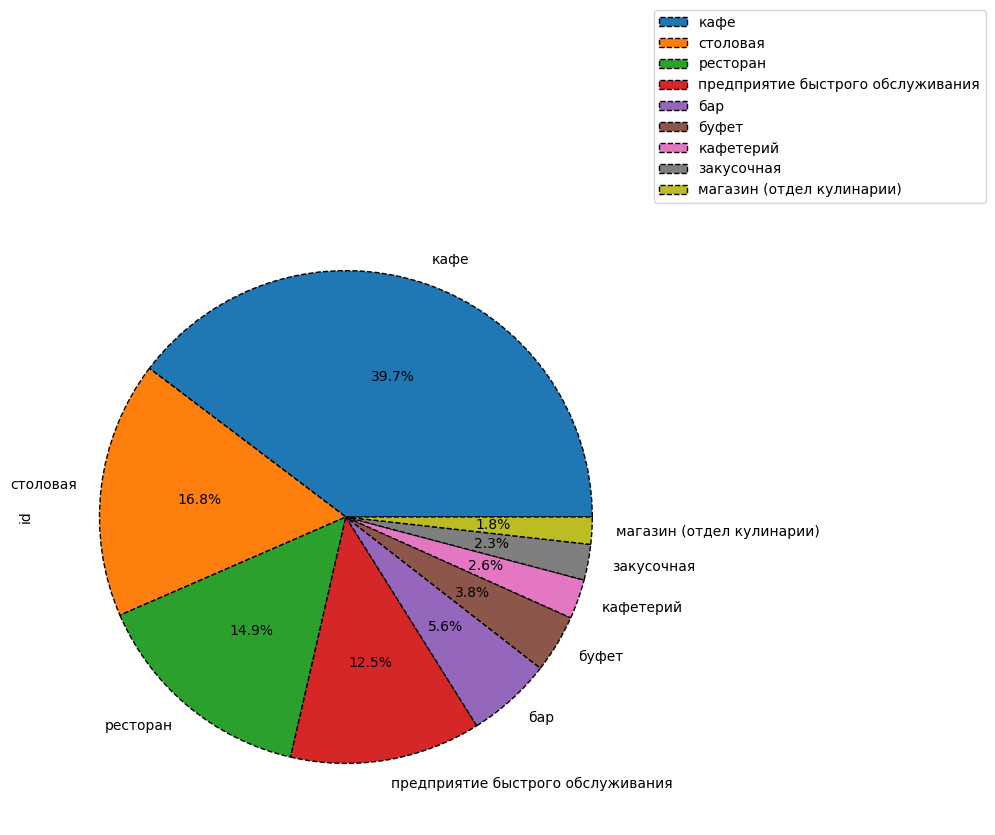

In [10]:
piebar['id'].plot(y='id', kind='pie', figsize=(8, 8), wedgeprops={'lw':1, 'ls':'--','edgecolor':"k"}, autopct='%1.1f%%', labels=piebar['object_type'])

plt.legend(loc=(01.00, 01.01))

    Ratio of types of food service establishments by quantity:
    * Cafes account for the largest share at 39.7%
    * Canteens are in second place at 16.8%
    * Restaurants are in third place at 14.9%
    * Fast food establishments are in fourth place at 12.5%

    The share of other types of establishments is less than 6%.

### 2.2. Ratio of Chain and Non-Chain Establishments<a class="anchor" id="2-2-bullet"></a>

In [11]:
df_rest_data['chain'].value_counts()

нет    12398
да      2968
Name: chain, dtype: int64

Text(0.5, 1.0, 'The Ratio of Chain and Non-chain\nEstablishments by Number')

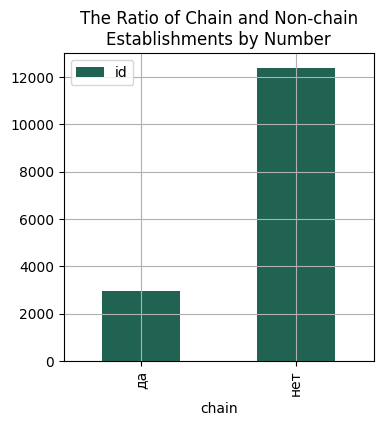

In [13]:
df_rest_data.pivot_table(index='chain', values='id', aggfunc='nunique').plot(kind='bar', grid=True, figsize=(4, 4), color='#216353')
plt.title('The Ratio of Chain and Non-chain\nEstablishments by Number')

    There are 4 times more non-chain establishments in Moscow

### 2.3. Type of Establishment Characterized by Chain Distribution<a class="anchor" id="2-3-bullet"></a>

In [14]:
df_chain_proportion = df_rest_data.pivot_table(index='object_type', columns='chain', values='id', aggfunc='count').reset_index()
df_chain_proportion['sum'] = df_chain_proportion['да'] + df_chain_proportion['нет']
df_chain_proportion['ratio'] = (df_chain_proportion['да'] / df_chain_proportion['sum']).round(2)
df_chain_proportion.sort_values(by='ratio', ascending=False)

chain,object_type,да,нет,sum,ratio
6,предприятие быстрого обслуживания,791,1132,1923,0.41
5,магазин (отдел кулинарии),78,195,273,0.29
7,ресторан,544,1741,2285,0.24
3,кафе,1396,4703,6099,0.23
2,закусочная,56,304,360,0.16
4,кафетерий,52,346,398,0.13
0,бар,37,819,856,0.04
1,буфет,11,574,585,0.02
8,столовая,3,2584,2587,0.00


Text(0.5, 1.0, 'The Share of Network Distribution for Each Public Catering Facility')

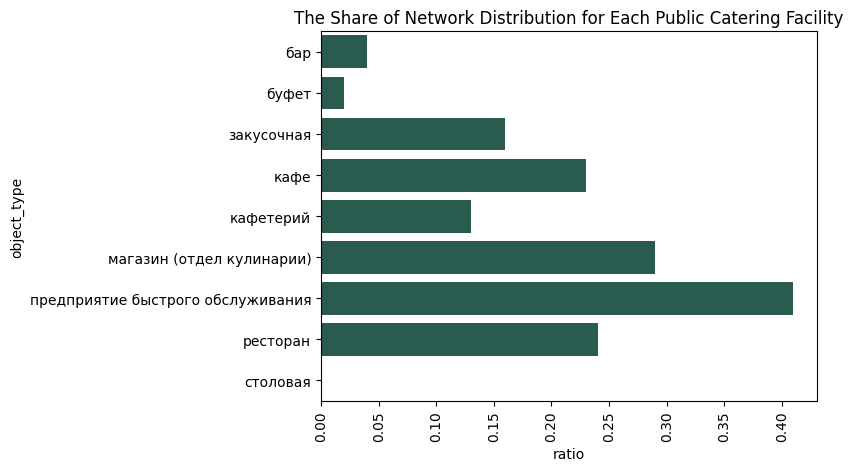

In [15]:
fig = ax = sns.barplot(x='ratio', y='object_type', data=df_chain_proportion, color='#216353')
plt.xticks(rotation=90)
plt.title('The Share of Network Distribution for Each Public Catering Facility')

* Chain distribution is primarily characteristic of fast food establishments.
41% of fast food establishments are chains.

* Stores (deli departments) are in second place, with 29% of establishments being chains.

* Restaurants and cafes are in third place, with 24% and 23%, respectively.

### 2.4. Chain Establishments: Relationship Between the Number of Establishments in a Chain and the Number of Seating<a class="anchor" id="2-4-bullet"></a>

In [16]:
df_chain = df_rest_data[df_rest_data['chain'] == 'да']

In [17]:
df_chain['number'].describe()

count    2968.000000
mean       52.919811
std        57.140644
min         0.000000
25%        15.000000
50%        40.000000
75%        72.000000
max       580.000000
Name: number, dtype: float64

(-10.0, 161.0)

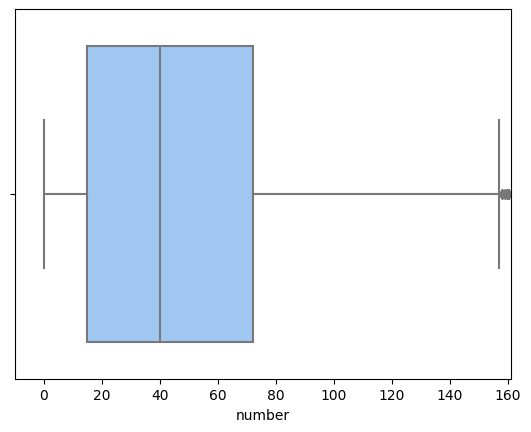

In [18]:
with plt.style.context('seaborn-pastel'):
    ax = sns.boxplot(x='number', data=df_chain)
plt.xlim(-10, 161)

In [19]:
np.percentile(df_chain['number'], [90, 95, 99])

array([120.  , 158.65, 275.33])

According to the data, chain establishments may not have seating. For example, in
shopping mall food courts, where there is a pickup point and a common area with seating,
which is not assigned to a specific cafe or food service establishment. Or, for example,
a pickup window at fast food chains.

25% of chain establishments have no more than 15 seats.

The average number of seats for chain establishments is 40.

75% of chain establishments have no more than 72 seats.

90% of chain establishments have no more than 120 seats.

The largest outlier is at a establishment with 580 seats.

**Let's take a closer look at establishments that have no or only one seat:**

    

In [20]:
number_1 = df_chain[df_chain['number'] <= 1]
number_1.head()

,id,object_name,chain,object_type,address,number
290,144091,КОФЕ С СОБОЙ,да,предприятие быстрого обслуживания,"город Москва, 1-я Тверская-Ямская улица, дом 1...",0
498,152450,Суши сет,да,предприятие быстрого обслуживания,"город Москва, Краснопрудная улица, дом 22-24",0
504,157035,Кофе с собой,да,кафетерий,"город Москва, Краснохолмская набережная, дом 1...",0
577,149220,Кофейня «Кофе Хаус»,да,кафе,"город Москва, Павелецкая площадь, дом 1А, стро...",0
938,154596,СтардогS,да,предприятие быстрого обслуживания,"город Москва, Профсоюзная улица, дом 2/22",0


In [21]:
number_1.groupby('object_type')['id'].count().reset_index().sort_values(by='id', ascending=False) 

,object_type,id
6,предприятие быстрого обслуживания,130
3,кафе,55
5,магазин (отдел кулинарии),37
2,закусочная,18
7,ресторан,18
4,кафетерий,16
1,буфет,8
0,бар,1


**Establishments with one or no seating:**

These are primarily quick-service establishments – 45.9%.
They are often located in food courts – dining areas in shopping malls, airports, or, in some cases, separate buildings (for example, Depot in Moscow), where customers
are offered services by several food establishments sharing a common dining area.

Cafes are in second place – 19.4%

Deli stores are in third place – 13.1%

    Let's look at what's typical for chain restaurants using the largest chain in the dataset, KFC, as an example.

In [22]:
df_chain_kfc = df_chain[df_chain['object_name'] == 'KFC']
df_chain_kfc

,id,object_name,chain,object_type,address,number
142,26142,KFC,да,ресторан,"город Москва, Бутырская улица, дом 89",67
301,24242,KFC,да,ресторан,"город Москва, улица Грузинский Вал, дом 28/45",40
339,72728,KFC,да,ресторан,"город Москва, Дубнинская улица, дом 30, корпус 1",70
726,69804,KFC,да,предприятие быстрого обслуживания,"город Москва, Можайское шоссе, дом 39",98
853,143264,KFC,да,предприятие быстрого обслуживания,"город Москва, 9-я Парковая улица, дом 30",44
...,...,...,...,...,...,...
15243,205439,KFC,да,предприятие быстрого обслуживания,"город Москва, улица Ленинская Слобода, дом 26,...",30
15244,210743,KFC,да,предприятие быстрого обслуживания,"город Москва, город Московский, улица Хабарова...",0
15245,205607,KFC,да,предприятие быстрого обслуживания,"город Москва, поселение Московский, Киевское ш...",30
15246,214867,KFC,да,кафе,"город Москва, Кутузовский проспект, дом 57",0


In [23]:
df_chain_kfc.groupby('object_type').agg({'object_type':['count'], 'number':['median']})

,object_type,number
,count,median
object_type,,
кафе,26,35
предприятие быстрого обслуживания,99,50
ресторан,30,40


We see that a single chain can have several types of food service establishments.

* For example, 63.9% of KFC chain restaurants are quick-service establishments with an average
seating capacity of 50.
* Restaurants are in second place at 19.4%, with an average seating capacity of 40.
* Cafés are in third place at 16.8%, with an average seating capacity of 35.

Let's see if this is typical for other chains, using the second-largest chain, Shokoladnitsa, as an example.

In [29]:
df_chain_chocolate = df_chain[df_chain['object_name'] == 'Шоколадница']
df_chain_chocolate.groupby('object_type').agg({'object_type':['count'], 'number':['median']})

,object_type,number
,count,median
object_type,,
бар,1,150
кафе,134,50
предприятие быстрого обслуживания,1,40
ресторан,5,72


    We see that the second chain has four types of food service establishments.
    The main type is a cafe. The number of seats also depends on the type of establishment.

**The relationship between the number of establishments in the chain and the number of seats**

    Let's see if there's a correlation between the number of establishments in the chain and the number of seats in those establishments.

In [32]:
cor_chain = df_chain.groupby('object_name').agg({'id':['count'], 'number':['median']})
cor_chain.columns = ['id_count', 'number_median']

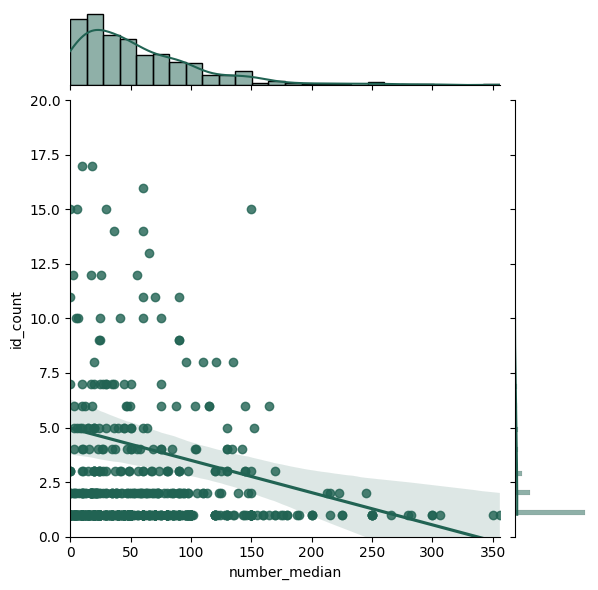

In [33]:
sns.jointplot(x="number_median", y="id_count", data=cor_chain, kind='reg', color='#216353')
plt.ylim(0, 20)
plt.show()

    We found a negative linear correlation.
    The fewer establishments in a chain, the more seats they have, and vice versa,
    the more establishments in a chain, the fewer seats.

### 2.5. Average Number of Seating for Each Type of Establishment<a class="anchor" id="2-5-bullet"></a>  

In [34]:
df_rest_data.pivot_table(index='object_type', values='number', aggfunc='median').round().sort_values(by='number', ascending=False)  

,number
object_type,
столовая,103
ресторан,80
бар,35
буфет,32
кафе,30
кафетерий,6
предприятие быстрого обслуживания,5
закусочная,0
магазин (отдел кулинарии),0


Text(0.5, 1.0, 'Average Number of Seats for Each Type of Catering Facility')

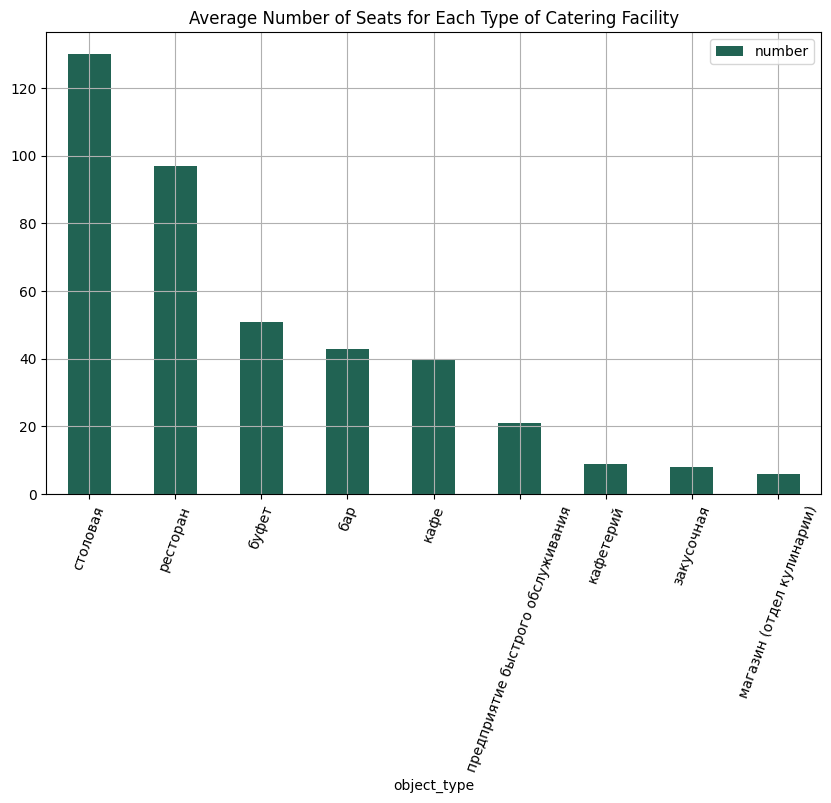

In [35]:
df_rest_data.pivot_table(index='object_type', values='number', aggfunc='mean').round().sort_values(by='number', ascending=False).plot(kind='bar', grid=True, figsize=(10, 6), color='#216353')
plt.xticks(rotation=70)
plt.title('Average Number of Seats for Each Type of Catering Facility')

Text(0.5, 1.0, 'Average Number of Seats for Each Type of Catering Facility')

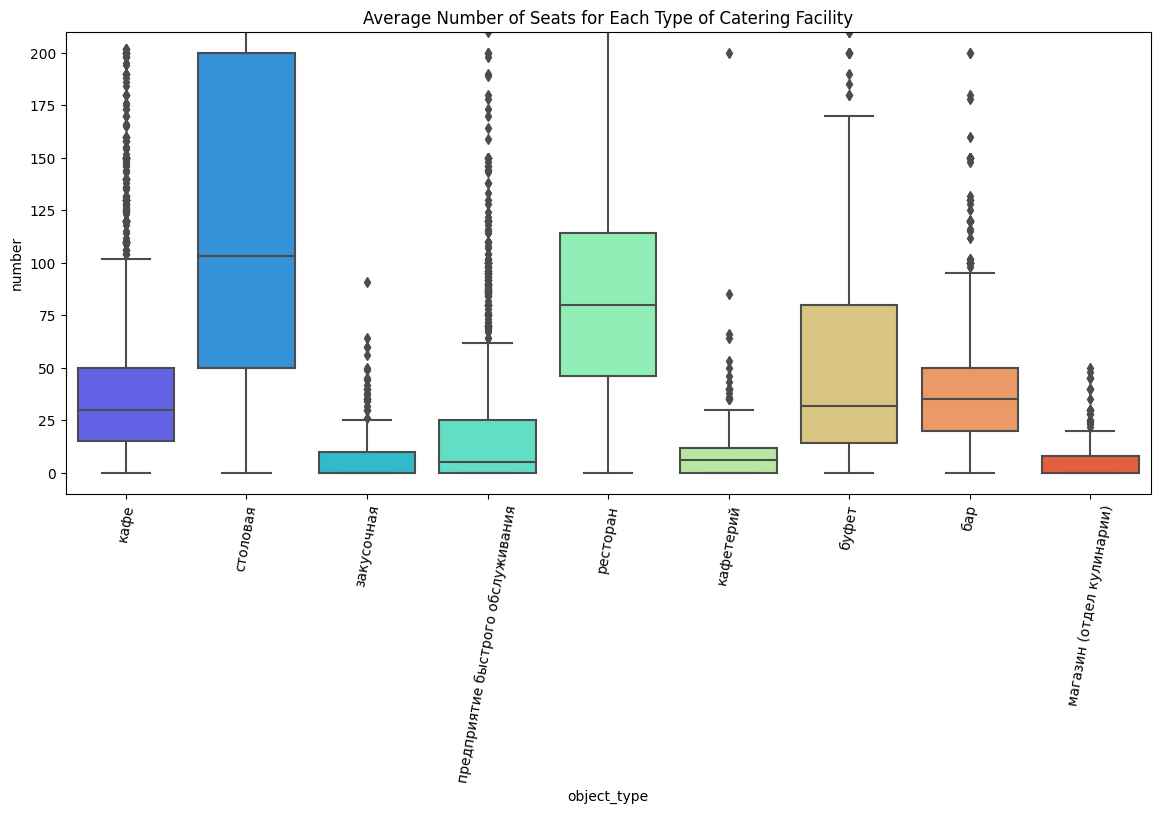

In [36]:
plt.figure(figsize=(14,6))
sns.boxplot(x="object_type", y="number", data=df_rest_data, palette='rainbow')
plt.ylim(-10, 210)
plt.xticks(rotation=80)
plt.title('Average Number of Seats for Each Type of Catering Facility')

**Canteen** has the largest average number of seats – 103.

The boxplot shows that 25% of canteens (lower quartile) have approximately 50 seats.
The upper quartile has approximately 200 seats.

Restaurants come in second. The average restaurant has 80 seats.
The boxplot shows that 25% of restaurants (lower quartile) have approximately 45 seats.
The upper quartile has approximately 120 seats.

The third-place group is **bars, buffets, and cafes**. These establishments have approximately 30-35 seats on average. The boxplot shows that 25% of establishments in this group (lower quartile) have approximately 20 seats.
The difference is in the upper quartile. While the upper quartile for cafes and bars is around 50 seats, for buffets it's higher, around 80.

The last group: **cafeteria, fast food establishment, diner, and store (deli department)**. This group is characterized by minimal seating capacity. The boxplot shows that establishments in this group have a lower quartile of 0 seats. The upper quartile for cafeterias, diner, and store (deli department) does not exceed 13 seats, while for fast food establishments it's 25 seats. The average for this group ranges from 0 to 5.


### 2.6. Separating "Streets" from the Address into a Separate Column<a class="anchor" id="2-6-bullet"></a>

In [37]:
df_rest_data['street'] = ''
def streets(row):
    address = row[4]
    address = address.split(', ')
    street = address[1]
    if  (((street.count('поселение') > 0) | 
          (street.count('поселок') > 0) |
          (street.count('деревня') > 0) |
          (street.count('город') > 0)) & 
         (len(address)>2)):
        address[1] = address[2]
    row[6] = address[1]
    return row

In [38]:
df_rest_data = df_rest_data.apply(streets, axis=1)

In [39]:
df_rest_data.head(5)

,id,object_name,chain,object_type,address,number,street
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48,улица Егора Абакумова
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35,улица Талалихина
2,24309,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95,Абельмановская улица
3,21894,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40,Абрамцевская улица
4,119365,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50,Абрамцевская улица


    Let's load a table with Moscow's streets, districts, and administrative districts,
    and merge it with the restaurant dataframe.

In [34]:
region_moscow = pd.read_excel('region_moscow.xlsx')

In [35]:
region_moscow.head()

,street,district,quantity_district,region,quantity_region
0,проспект Мира,"Северо-Восточный, Центральный",2,"Алексеевский, Марьина роща, Мещанский, Останк...",7
1,Профсоюзная улица,Юго-Западный,1,"Академический, Коньково, Обручевский, Тёплый С...",6
2,Ленинградский проспект,Северный,1,"Аэропорт, Беговой, Сокол, Хорошёвский",4
3,Пресненская набережная,Центральный,1,Пресненский,1
4,Варшавское шоссе,Юго-Западный,1,"Северное Бутово, Южное Бутово, Донской, Нагат...",8


In [36]:
df_rest_data_region = df_rest_data.merge(region_moscow,on='street')
df_rest_data_region.head()

,id,object_name,chain,object_type,address,number,street,district,quantity_district,region,quantity_region
0,22139,ХуанХэ,нет,ресторан,"город Москва, 1-й Балтийский переулок, дом 3/25",60,1-й Балтийский переулок,Северный,1,Аэропорт,1
1,25833,АЗЕРБАЙДЖАН,нет,ресторан,"город Москва, улица Демьяна Бедного, дом 4",180,улица Демьяна Бедного,Северо-Западный,1,Хорошёво-Мневники,1
2,155973,Кафе «Андерсон»,да,кафе,"город Москва, Варшавское шоссе, дом 2",150,Варшавское шоссе,Юго-Западный,1,"Северное Бутово, Южное Бутово, Донской, Нагат...",8
3,23618,Кафе «Subway»,да,кафе,"город Москва, Варшавское шоссе, дом 7, корпус 1",36,Варшавское шоссе,Юго-Западный,1,"Северное Бутово, Южное Бутово, Донской, Нагат...",8
4,155852,Кафе «Ламаджо»,нет,кафе,"город Москва, Варшавское шоссе, дом 29",30,Варшавское шоссе,Юго-Западный,1,"Северное Бутово, Южное Бутово, Донской, Нагат...",8


### 2.7. Top 10 Streets by Number of Facilities<a class="anchor" id="2-7-bullet"></a>

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), <a list of 10 Text xticklabel objects>)

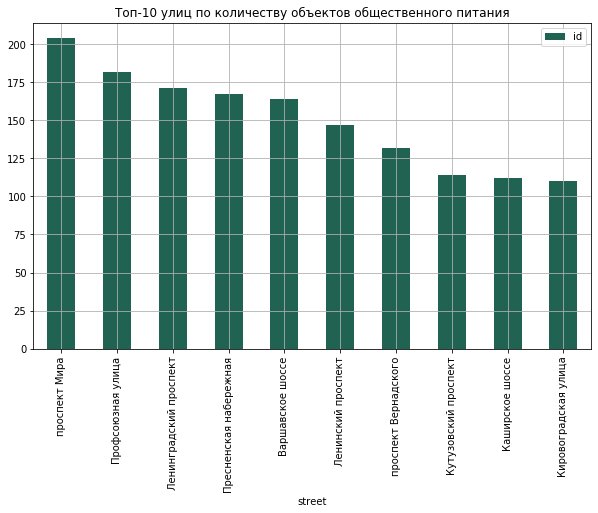

In [37]:
rest_streets_top10 = df_rest_data_region.pivot_table(index='street', values='id', aggfunc='count').round().sort_values(by='id', ascending=False).head(10)
rest_streets_top10.plot(kind='bar', grid=True, figsize=(10, 6), color='#216353')
plt.title('Топ-10 улиц по количеству объектов общественного питания')
plt.xticks(rotation=90)

    Let's see in which areas of Moscow these streets are located.

In [38]:
rest_streets = df_rest_data_region.groupby(['street', 'quantity_region', 'region'])['id'].count().reset_index().sort_values(by='id', ascending=False)
pd.set_option('display.max_colwidth', -1)
rest_streets.head(10)

,street,quantity_region,region,id
75,проспект Мира,7,"Алексеевский, Марьина роща, Мещанский, Останкинский, Ростокино, Свиблово, Ярославский",204
66,Профсоюзная улица,6,"Академический, Коньково, Обручевский, Тёплый Стан, Черёмушки, Ясенево",182
63,Ленинградский проспект,4,"Аэропорт, Беговой, Сокол, Хорошёвский",171
65,Пресненская набережная,1,Пресненский,167
59,Варшавское шоссе,8,"Северное Бутово, Южное Бутово, Донской, Нагатино-Садовники, Нагорный, Северное Чертаново, Центральное Чертаново, Южное Чертаново",164
64,Ленинский проспект,8,"Гагаринский, Донской, Ломоносовский, Обручевский, Проспект Вернадского, Тёплый Стан, Тропарёво-Никулино, Якиманка",147
74,проспект Вернадского,5,"Гагаринский, Ломоносовский, Проспект Вернадского, Раменки, Тропарёво-Никулино",132
62,Кутузовский проспект,2,"Дорогомилово, Фили-Давыдково",114
60,Каширское шоссе,4,"Москворечье-Сабурово, Нагатино-Садовники, Северное Орехово-Борисово, Южное Орехово-Борисово",112
61,Кировоградская улица,3,"Северное Чертаново, Центральное Чертаново, Южное Чертаново",110


    The streets with the most food service establishments
    cross several Moscow districts. Varshavskoe Shosse and Leninsky Prospekt
    stretch across eight districts, and Prospekt Mira across seven districts. The only exception is
    Presnenskaya Embankment, which is located in a single district. Consequently, these streets are long,
    which explains the large number of establishments located on them.

### 2.8. Distribution of Seating Capacity for Streets with a Large Number of Food Service Facilities<a class="anchor" id="2-8-bullet"></a>

In [39]:
top_10_streets_list = ['проспект Мира', 'Профсоюзная улица', 'Ленинградский проспект', 'Пресненская набережная', 'Варшавское шоссе', 'Ленинский проспект', 'проспект Вернадского', 'Кутузовский проспект', 'Каширское шоссе', 'Кировоградская улица']

In [40]:
top_10_streets_table = df_rest_data_region.query('street in @top_10_streets_list')

In [41]:
cor_top_10_streets = top_10_streets_table.groupby(['street']).agg({'id':['count'], 'number':['median']})
cor_top_10_streets.head()

,id,number
,count,median
street,,
Варшавское шоссе,164,30.0
Каширское шоссе,112,25.0
Кировоградская улица,110,30.0
Кутузовский проспект,114,40.0
Ленинградский проспект,171,40.0


(0, 250)

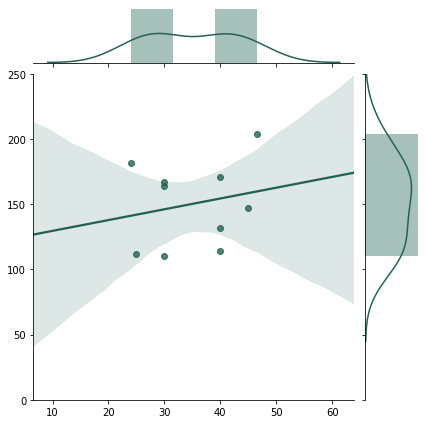

In [42]:
sns.jointplot(x="number", y="id", data=cor_top_10_streets, kind='reg', color='#216353')
plt.ylim(0, 250)

    We see a slight positive linear correlation.
    The more establishments on the street, the more seats they have.

### 2.9. Neighborhoods with Streets with Only One Establishment<a class="anchor" id="2-9-bullet"></a>

In [43]:
streets_one_rest = df_rest_data.groupby('street')['id'].count().reset_index()

In [44]:
qty = streets_one_rest[streets_one_rest['id'] == 1]

In [45]:
qty['street'].count()

722

    The dataframe contains 722 streets with one food service establishment.
    Let's look at the districts in which they are located. 

In [46]:
one_rest_streets_with_region = df_rest_data_region.groupby(['street', 'region', 'district'])['id'].count().reset_index()
one_rest_streets_with_region = one_rest_streets_with_region[one_rest_streets_with_region['id'] == 1]
one_rest_streets_with_region.head(5) 

,street,region,district,id
0,1-й Балтийский переулок,Аэропорт,Северный,1
1,1-й Басманный переулок,"Басманный, Красносельский",Центральный,1
2,1-й Ботанический проезд,Свиблово,Северо-Восточный,1
3,1-й Вешняковский проезд,Рязанский,Юго-Восточный,1
4,1-й Голутвинский переулок,Якиманка,Центральный,1


In [47]:
one_rest_streets_with_region['region'].nunique()

77

In [48]:
print(one_rest_streets_with_region['region'].unique())

['Аэропорт' 'Басманный, Красносельский' 'Свиблово' 'Рязанский' 'Якиманка'
 'поселение Троицк' 'Хамовники' 'Соколиная Гора' 'Даниловский район'
 ' Даниловский ' 'Красносельский и Мещанский  ' ' Таганский' 'Пресненский'
 'Печатники' 'Сокольники' 'Замоскворечье' 'Хорошёвский' 'Арбат'
 ' Алексеевский' 'Текстильщики' 'Ростокино' 'Раменки' 'Хорошёво-Мневники'
 'Якиманка ' 'Покровское-Стрешнево' 'Марьина роща' 'Богородское'
 'Нижегородский' 'Тверской' 'Лосиноостровский' 'Преображенское'
 'Ново-Переделкино' 'Хорошево-Мневники' 'Гольяново' 'Измайлово'
 'Восточное Измайлово' 'Беговой' 'Донской' 'Лефортово' 'Красносельский'
 'Хорошевский' 'Войковский' 'Бутырский' 'Южное Тушино' ' Коптево'
 'Отрадное' 'Преображенский' 'Южное Бутово' 'Митино' 'Северное Бутово'
 'Ясенево' 'Капотня' 'Фили-Давыдково' 'Алексеевский'
 'Москворечье-Сабурово' 'Можайский' 'Можайский район' 'Южнопортовый'
 'Некрасовка' 'Щукино' 'Таганский' 'Косино-Ухтомский' 'Царицыно'
 'Дорогомилово' 'Тимирязевский' 'поселение Московский' 

    Streets with just one food service establishment are located throughout almost all of Moscow, namely in 77 districts. Let's look at the administrative districts in which these districts are located.

In [49]:
one_rest_streets_with_region['district'].nunique()

11

In [58]:
sns.set_palette('coolwarm')

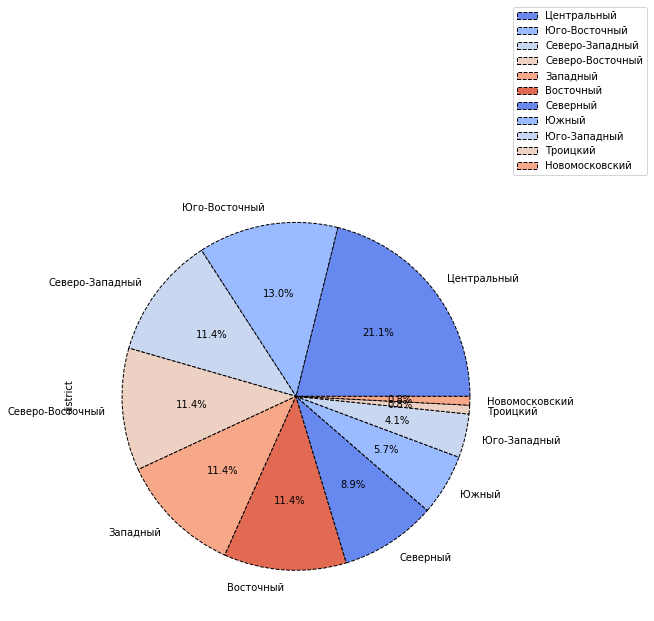

In [65]:
one_rest_streets_with_region['district'].value_counts(ascending=False).plot(y='district', kind='pie', figsize=(8, 8), wedgeprops={'lw':1, 'ls':'--','edgecolor':"k"}, autopct='%1.1f%%')
plt.legend(loc=(01.00, 01.01))

    The Central Administrative Okrug, located in the city center, ranks first with 21.1%.
    It can be assumed that the streets with one establishment each are small
    side streets in the city center.

### Step 3. General Conclusion<a class="anchor" id="3-bullet"></a>

1. The table contains 10,393 unique names. The top three places by number are "generic names" - Canteen, Cafe, Shawarma. These are places that have no name or don't have a specific name. KFC and Shokoladnitsa are in 4th and 5th place by number of establishments.

2. Ratio of types of food service establishments by number:

* Cafes account for the largest share of the food service establishments by number - 39.7%
* Canteens are in second place - 16.8%
* Restaurants are in third place - 14.9%
* Fast food establishments are in fourth place - 12.5%
* The share of other types of establishments is less than 6% (bars, buffets, cafeterias, snack bars, stores
(deli department))

3. Ratio of chain and non-chain establishments by number:

* Non-chain food service establishments - 12,398 units
* Chain restaurants - 2,968 units.

Therefore, Moscow has four times as many non-chain restaurants.

4. Types of catering establishments characterized by chain distribution:

* Chain distribution is primarily typical for fast food establishments. 41% of establishments are chains.

* Stores (deli departments) rank second, with 29% of establishments being chains.

* Restaurants and cafes rank third, with 24% and 23%, respectively.

5. Dependence of seating in chain establishments on the number of establishments within the chain:

According to the data, chain establishments may not have seating. For example, in shopping mall food courts, where there is a pickup point and a common area with seating that is not assigned to a specific cafe or catering establishment. Or, for example, at a pickup window in a fast food chain.

Establishments with one or no seats:

* These are primarily quick-service establishments – 45.9%. They are located in food courts – food courts in shopping malls, airports, or, in some cases, separate buildings (e.g., Depot), where customers are served by several food service establishments sharing a common dining area.
* Cafés are in second place – 19.4%
* Stores (deli departments) are in third place – 13.1%

Analysis of the number of seats for all chain establishments:

* 25% of chain establishments have no more than 15 seats.
* The average number of seats for chain establishments is 40.
* 75% of chain establishments have no more than 72 seats.
* 90% of chain establishments have no more than 120 seats.

The analysis revealed that a single chain can have several types of food service establishments, and the average number of seats varies depending on the type.

* For example, 63.9% of KFC establishments are fast food establishments, with an average number of seats of 50.
* Restaurants are in second place within the KFC chain, with 19.4% having an average number of seats of 40.
* Cafes are in third place within the KFC chain, with 16.8% having an average number of seats of 35.

When analyzing the relationship between the number of establishments in a chain and the number of seats in those establishments, a negative linear correlation was found. The fewer establishments in a chain, the more seats they have, and vice versa, the more establishments in a chain, the fewer seats.

6. Average number of seats for each type of food service establishment.

*Canteens* have the largest average number of seats – 103.
25% of canteens (lower quartile) have around 50 seats.
The upper quartile has around 200 seats.

*Restaurants* come in second. The average restaurant has 80 seats.
25% of restaurants (lower quartile) have around 45 seats.
The upper quartile has around 120 seats.

Third place goes to *bars, buffets, and cafes*. These establishments have an average of 30-35 seats. 25% of establishments in this group (lower quartile) have around 20 seats.
The difference is in the upper quartile. While the upper quartile for cafes and bars is around 50 seats, for buffets it's higher, around 80.

The last group: *cafeterias, fast-food establishments, diner, and stores (deli departments). This group is characterized by minimal seating capacity. The lower quartile for establishments in this group is 0 seats. The upper quartile for cafeterias, diner, and stores (deli departments) does not exceed 13 seats, while for fast-food establishments it's 25 seats. The average for this group ranges from 0 to 5.

7. Top 10 streets by number of food service establishments:

Prospekt Mira, Profsoyuznaya Street, Leningradsky Prospekt, Presnenskaya Embankment, Varshavskoe Shosse, Leninsky Prospekt, Vernadskogo Prospekt, Kutuzovsky Prospekt, Kashirskoe Shosse, and Kirovogradskaya Street.

These streets pass through several districts of Moscow. For example, Varshavskoe Shosse and Leninsky Prospekt stretch across eight districts, while Prospekt Mira stretches across seven districts. The only exception is Presnenskaya Embankment, which is located in a single district. Consequently, these streets are long, which explains the large number of establishments located on them.

8. Distribution of seating capacity for streets with a large number of food service establishments:

We see a slight positive linear correlation. The more establishments on a street, the more seats they have.

9. Streets with one food service establishment:

The dataframe contains 722 streets with one food service establishment. These streets are located throughout almost all of Moscow, namely in 77 districts. These districts are located in all administrative districts.

The Central Administrative District, located in the city center, has the highest number of streets with one food service establishment, accounting for 21.1%. It can be assumed that the streets with one establishment are small side streets in the city center.

District statistics:
- Central - 21.1%
- Southeast - 13%
- Northeast - 11.4%
- East - 11.4%
- West - 11.4%
- Northwest - 11.4%
- North - 8.94%
- South - 5.69%
- Southwest - 4.07%
- Troitsky - 0.8%
- Novomoskovsky - 0.8%

10. When choosing a café location, information about streets with one establishment or the largest number of establishments is not enough. The following factors must also be considered:

* The price range of our café: affordable or expensive, trendy. Based on this, you should choose a district/street. Analyze your closest competitors in the same price range.
* The number of people passing by the café entrance per unit of time. * Transportation accessibility (including public transportation), parking options
* The composition of the area's residents, workers, and casual visitors. This is important because, for example, if you locate in an office district, it can be quite difficult to fill the cafe on weekends.
* Analysis of nearby facilities – are there business centers, institutions, universities, shopping malls, etc.)
* The establishment's cuisine is unknown (European, Asian, etc.). Once the initial interest in robots fades, customers will evaluate the establishment's cuisine. It's important to understand what competitors will be in the vicinity of the new cafe, and in what numbers. There's no point in opening an eighth sushi bar.